In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Literal,Annotated
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

In [9]:
load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [10]:
# Create a State

class JokeState(TypedDict):
    topic : str
    joke : str
    explaination : str

In [11]:
def generate_joke(state : JokeState) -> JokeState:

    topic = state['topic']
    prompt = f"Generate a joke on the topic - {topic}"

    result = model.invoke(prompt).content

    return {'joke' : result}

In [12]:
def generate_explaination(state : JokeState) -> JokeState:

    joke = state['joke']
    prompt = f"Explain the joke  - {joke}"

    result = model.invoke(prompt).content

    return {'explaination' : result}

In [17]:
# Create a Graph
graph = StateGraph(JokeState)

# Create a node
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explaination', generate_explaination)


# Create edges
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explaination')
graph.add_edge('generate_explaination', END)

# Load a checkpointer object
checkpointer = InMemorySaver()

# Compile the Graph
workflow = graph.compile(checkpointer=checkpointer)

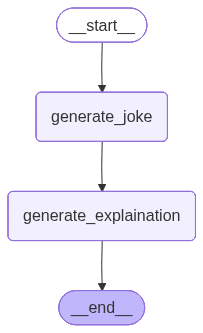

In [18]:
workflow

In [19]:
config1 = {'configurable': {'thread_id' : 1}}

joke1 = workflow.invoke({'topic' : 'pizza'}, config=config1)

print(joke1)

{'topic': 'pizza', 'joke': 'Why did the pizza maker go to jail?\n\nBecause he *kneaded* to be punished for his crimes against dough!', 'explaination': 'This is a classic pun joke! Here\'s the breakdown:\n\n*   **"Kneaded"**: This word sounds exactly like "needed."\n*   **"Kneading"** is a fundamental process in making pizza dough. It involves pressing and folding the dough to develop gluten, which makes the dough elastic and chewy.\n*   **The Joke**: The punchline plays on the double meaning.\n    *   Literally, the pizza maker "kneaded" the dough.\n    *   Figuratively, the joke implies that the pizza maker "needed" to be punished for some unspecified "crimes against dough."\n\n**Why it\'s funny (or meant to be):**\n\nThe humor comes from the unexpected substitution of a word that sounds the same ("kneaded" for "needed") and the absurdity of committing "crimes against dough." It\'s a lighthearted and silly play on words.'}


In [20]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to jail?\n\nBecause he *kneaded* to be punished for his crimes against dough!', 'explaination': 'This is a classic pun joke! Here\'s the breakdown:\n\n*   **"Kneaded"**: This word sounds exactly like "needed."\n*   **"Kneading"** is a fundamental process in making pizza dough. It involves pressing and folding the dough to develop gluten, which makes the dough elastic and chewy.\n*   **The Joke**: The punchline plays on the double meaning.\n    *   Literally, the pizza maker "kneaded" the dough.\n    *   Figuratively, the joke implies that the pizza maker "needed" to be punished for some unspecified "crimes against dough."\n\n**Why it\'s funny (or meant to be):**\n\nThe humor comes from the unexpected substitution of a word that sounds the same ("kneaded" for "needed") and the absurdity of committing "crimes against dough." It\'s a lighthearted and silly play on words.'}, next=(), config={'configurable': {'threa

In [24]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to jail?\n\nBecause he *kneaded* to be punished for his crimes against dough!', 'explaination': 'This is a classic pun joke! Here\'s the breakdown:\n\n*   **"Kneaded"**: This word sounds exactly like "needed."\n*   **"Kneading"** is a fundamental process in making pizza dough. It involves pressing and folding the dough to develop gluten, which makes the dough elastic and chewy.\n*   **The Joke**: The punchline plays on the double meaning.\n    *   Literally, the pizza maker "kneaded" the dough.\n    *   Figuratively, the joke implies that the pizza maker "needed" to be punished for some unspecified "crimes against dough."\n\n**Why it\'s funny (or meant to be):**\n\nThe humor comes from the unexpected substitution of a word that sounds the same ("kneaded" for "needed") and the absurdity of committing "crimes against dough." It\'s a lighthearted and silly play on words.'}, next=(), config={'configurable': {'thre

In [ ]:
config2 = {'configurable' : {'thread_id' : 2}}

joke2 = workflow.invoke({'topic' : 'pasta'}, config=config2)

print(joke2)

{'topic': 'pasta', 'joke': "Why did the spaghetti break up with the meatball?\n\nBecause he felt like he was always being *sauced* into things he didn't want to do!", 'explaination': 'This joke is a pun that plays on the double meaning of the word "sauced."\n\nHere\'s the breakdown:\n\n*   **Literal Meaning (Food):** In the context of spaghetti and meatballs, "sauced" refers to being covered or mixed with sauce. This is a common and expected part of a spaghetti and meatballs dish.\n\n*   **Figurative Meaning (Slang):** In slang, "sauced" means to be **drunk** or intoxicated. It can also imply being **forced or pressured** into something.\n\n**The Joke\'s Punchline:**\n\nThe spaghetti is saying that the meatball felt like it was constantly being **forced** or **pressured** into situations it didn\'t want to be in, much like how a person might feel when they\'re "sauced" (drunk) and making bad decisions or getting into trouble.\n\n**Why it\'s funny:**\n\nThe humor comes from the unexpect

In [ ]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': "Why did the spaghetti break up with the meatball?\n\nBecause he felt like he was always being *sauced* into things he didn't want to do!", 'explaination': 'This joke is a pun that plays on the double meaning of the word "sauced."\n\nHere\'s the breakdown:\n\n*   **Literal Meaning (Food):** In the context of spaghetti and meatballs, "sauced" refers to being covered or mixed with sauce. This is a common and expected part of a spaghetti and meatballs dish.\n\n*   **Figurative Meaning (Slang):** In slang, "sauced" means to be **drunk** or intoxicated. It can also imply being **forced or pressured** into something.\n\n**The Joke\'s Punchline:**\n\nThe spaghetti is saying that the meatball felt like it was constantly being **forced** or **pressured** into situations it didn\'t want to be in, much like how a person might feel when they\'re "sauced" (drunk) and making bad decisions or getting into trouble.\n\n**Why it\'s funny:**\n\nThe humor co

In [29]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': "Why did the spaghetti break up with the meatball?\n\nBecause he felt like he was always being *sauced* into things he didn't want to do!", 'explaination': 'This joke is a pun that plays on the double meaning of the word "sauced."\n\nHere\'s the breakdown:\n\n*   **Literal Meaning (Food):** In the context of spaghetti and meatballs, "sauced" refers to being covered or mixed with sauce. This is a common and expected part of a spaghetti and meatballs dish.\n\n*   **Figurative Meaning (Slang):** In slang, "sauced" means to be **drunk** or intoxicated. It can also imply being **forced or pressured** into something.\n\n**The Joke\'s Punchline:**\n\nThe spaghetti is saying that the meatball felt like it was constantly being **forced** or **pressured** into situations it didn\'t want to be in, much like how a person might feel when they\'re "sauced" (drunk) and making bad decisions or getting into trouble.\n\n**Why it\'s funny:**\n\nThe humor c